In [29]:
import numpy as np
import pandas as pd
import re
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

print('TensorFlow version:', tf.__version__)
print('All libraries loaded!')

TensorFlow version: 2.21.0
All libraries loaded!


In [30]:
NAZARIO_PATH = r'C:\Users\leeja\Downloads\Phishing-Email-Detection-Under-Adversarial-Attack-Comparing-MLP-Naive-Bayes-and-Logistic-Regression\Nazario.csv\Nazario.csv'
SPAM_PATH    = r'C:\Users\leeja\Downloads\Phishing-Email-Detection-Under-Adversarial-Attack-Comparing-MLP-Naive-Bayes-and-Logistic-Regression\spam_ham_dataset.csv\spam_ham_dataset.csv'

nazario = pd.read_csv(NAZARIO_PATH)
spam    = pd.read_csv(SPAM_PATH)

print('Nazario columns:', nazario.columns.tolist())
print('Spam columns:   ', spam.columns.tolist())

Nazario columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']
Spam columns:    ['Unnamed: 0', 'label', 'text', 'label_num']


In [31]:
nazario_clean = nazario[['body', 'label']].copy()
nazario_clean.columns = ['text', 'label']

spam_clean = spam[['text', 'label_num']].copy()
spam_clean.columns = ['text', 'label']

df = pd.concat([nazario_clean, spam_clean], ignore_index=True)
df.dropna(inplace=True)
df['label'] = df['label'].astype(int)
df.reset_index(drop=True, inplace=True)

print(f'Total samples : {len(df)}')
print(df['label'].value_counts())
print('0 = Legit  |  1 = Phishing/Spam')

Total samples : 6736
label
0    3672
1    3064
Name: count, dtype: int64
0 = Legit  |  1 = Phishing/Spam


In [32]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' url ', text)
    text = re.sub(r'\d+', ' num ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)
print('Cleaning done!')
print('Sample:', df['text_clean'].iloc[0][:200])

Cleaning done!
Sample: this text is part of the internal format of your mail folder and is not a real message it is created automatically by the mail system software if deleted important folder data will be lost and it will


In [33]:
X_text = df['text_clean'].values
y      = df['label'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train_text)} samples')
print(f'Test : {len(X_test_text)} samples')

Train: 5388 samples
Test : 1348 samples


In [34]:
# TF-IDF for NB and LR — fewer features to save RAM
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

print('TF-IDF shape:', X_train_tfidf.shape)

TF-IDF shape: (5388, 5000)


In [35]:
# Character substitution
CHAR_MAP = {'a':'@', 'o':'0', 'i':'1', 'e':'3', 's':'$', 'l':'1', 'g':'9', 't':'7'}

def substitute_chars(text):
    return ''.join(CHAR_MAP.get(c, c) for c in str(text))

X_test_manip_text  = np.array([substitute_chars(t) for t in X_test_text])
X_test_manip_tfidf = tfidf.transform(X_test_manip_text)

print('Original   :', X_test_text[0][:80])
print('Manipulated:', X_test_manip_text[0][:80])

Original   : subject new turn ons tom production commenced to flow as stated below please cre
Manipulated: $ubj3c7 n3w 7urn 0n$ 70m pr0duc710n c0mm3nc3d 70 f10w @$ $7@73d b310w p13@$3 cr3


In [36]:
# Robust training data for MLP
X_train_manip = [substitute_chars(t) for t in X_train_text]  # plain list, no np.array

X_train_robust_text = list(X_train_text) + X_train_manip
y_train_robust      = np.concatenate([y_train, y_train])

tfidf_robust    = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)
X_train_robust  = tfidf_robust.fit_transform(X_train_robust_text)

X_test_robust_clean = tfidf_robust.transform(X_test_text)
X_test_robust_manip = tfidf_robust.transform(X_test_manip_text)

print(f'Robust training size: {X_train_robust.shape}')

Robust training size: (10776, 5000)


In [37]:
# Helper functions
results_clean = {}
results_manip = {}
roc_data      = {}

def evaluate(name, y_true, y_pred, y_prob, split='clean'):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)

    fnr = 1 - tpr
    eer = float(fpr[np.nanargmin(np.abs(fnr - fpr))])

    metrics = dict(Accuracy=acc, F1=f1, Precision=prec, Recall=rec, AUC=roc_auc, EER=eer)

    if split == 'clean':
        results_clean[name] = metrics
    else:
        results_manip[name] = metrics

    if name not in roc_data:
        roc_data[name] = {}
    roc_data[name][split] = (fpr, tpr, roc_auc)

    print(f'\n=== {name}  [{split.upper()}] ===')
    print(classification_report(y_true, y_pred, target_names=['Legit', 'Phishing']))
    print(f'AUC : {roc_auc:.4f}')
    print(f'EER : {eer:.4f}  (lower is better)')
    return metrics


def plot_cm(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Phishing'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=True)
    ax.set_title(title, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history.history['accuracy']) + 1)

    axes[0].plot(epochs, history.history['accuracy'],     label='Train', linewidth=2, color='#2196F3')
    axes[0].plot(epochs, history.history['val_accuracy'], label='Val',   linewidth=2, color='#2196F3', linestyle='--')
    axes[0].set_title(f'{model_name} — Accuracy per Epoch', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.4)

    axes[1].plot(epochs, history.history['loss'],     label='Train', linewidth=2, color='tomato')
    axes[1].plot(epochs, history.history['val_loss'], label='Val',   linewidth=2, color='tomato', linestyle='--')
    axes[1].set_title(f'{model_name} — Loss per Epoch', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Binary Cross-Entropy Loss')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

print('Helpers ready!')

Helpers ready!


Training Naive Bayes...

=== Naive Bayes  [CLEAN] ===
              precision    recall  f1-score   support

       Legit       0.95      0.93      0.94       735
    Phishing       0.92      0.95      0.93       613

    accuracy                           0.94      1348
   macro avg       0.94      0.94      0.94      1348
weighted avg       0.94      0.94      0.94      1348

AUC : 0.9842
EER : 0.0585  (lower is better)


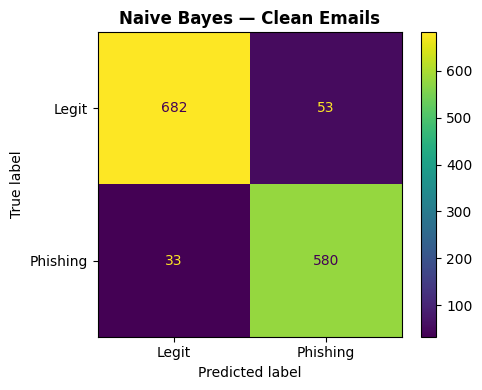

In [38]:
# Naive Bayes — Clean
print('Training Naive Bayes...')
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

nb_pred_clean = nb.predict(X_test_tfidf)
nb_prob_clean = nb.predict_proba(X_test_tfidf)[:, 1]
evaluate('Naive Bayes', y_test, nb_pred_clean, nb_prob_clean, split='clean')
plot_cm(y_test, nb_pred_clean, 'Naive Bayes — Clean Emails')


=== Naive Bayes  [MANIP] ===
              precision    recall  f1-score   support

       Legit       0.71      0.59      0.64       735
    Phishing       0.59      0.71      0.64       613

    accuracy                           0.64      1348
   macro avg       0.65      0.65      0.64      1348
weighted avg       0.65      0.64      0.64      1348

AUC : 0.7330
EER : 0.3442  (lower is better)


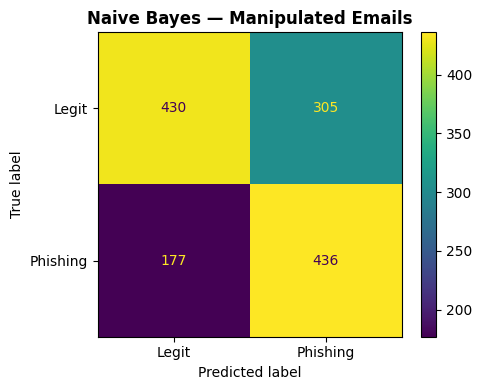

In [39]:
# Naive Bayes — Manipulated
nb_pred_manip = nb.predict(X_test_manip_tfidf)
nb_prob_manip = nb.predict_proba(X_test_manip_tfidf)[:, 1]
evaluate('Naive Bayes', y_test, nb_pred_manip, nb_prob_manip, split='manip')
plot_cm(y_test, nb_pred_manip, 'Naive Bayes — Manipulated Emails')

Training Logistic Regression...

=== Logistic Regression  [CLEAN] ===
              precision    recall  f1-score   support

       Legit       0.99      0.96      0.97       735
    Phishing       0.95      0.99      0.97       613

    accuracy                           0.97      1348
   macro avg       0.97      0.97      0.97      1348
weighted avg       0.97      0.97      0.97      1348

AUC : 0.9970
EER : 0.0286  (lower is better)


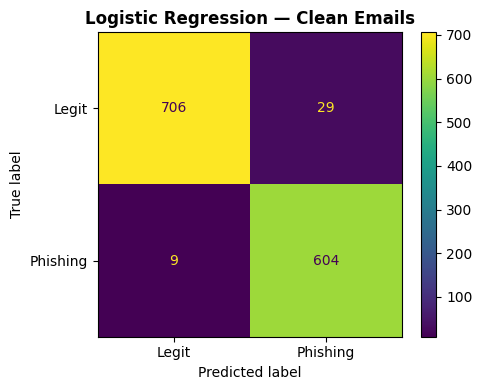

In [40]:
# Logistic Regression — Clean
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

lr_pred_clean = lr.predict(X_test_tfidf)
lr_prob_clean = lr.predict_proba(X_test_tfidf)[:, 1]
evaluate('Logistic Regression', y_test, lr_pred_clean, lr_prob_clean, split='clean')
plot_cm(y_test, lr_pred_clean, 'Logistic Regression — Clean Emails')


=== Logistic Regression  [MANIP] ===
              precision    recall  f1-score   support

       Legit       0.90      0.29      0.44       735
    Phishing       0.53      0.96      0.68       613

    accuracy                           0.60      1348
   macro avg       0.71      0.63      0.56      1348
weighted avg       0.73      0.60      0.55      1348

AUC : 0.7998
EER : 0.2571  (lower is better)


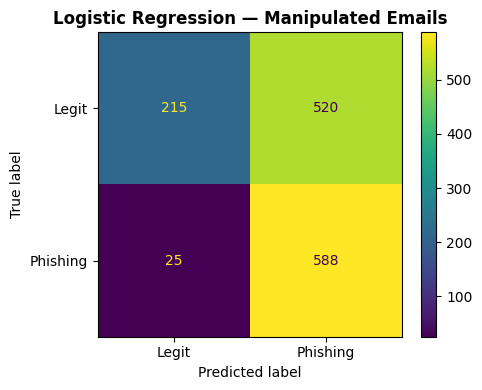

In [41]:
# Logistic Regression — Manipulated
lr_pred_manip = lr.predict(X_test_manip_tfidf)
lr_prob_manip = lr.predict_proba(X_test_manip_tfidf)[:, 1]
evaluate('Logistic Regression', y_test, lr_pred_manip, lr_prob_manip, split='manip')
plot_cm(y_test, lr_pred_manip, 'Logistic Regression — Manipulated Emails')

In [42]:
# ── ROBUST NB AND LR ──────────────────────────────────────────
# Retrain NB and LR on robust data (clean + manipulated)
# so we can compare all 3 models under the same conditions

# Robust TF-IDF for NB and LR (same vectorizer used for MLP)
X_train_robust_nb = tfidf_robust.transform(list(X_train_text) + [substitute_chars(t) for t in X_train_text])

print("Training Robust Naive Bayes...")
nb_robust = MultinomialNB()
nb_robust.fit(X_train_robust_nb, y_train_robust)
print("Done!")

print("Training Robust Logistic Regression...")
lr_robust = LogisticRegression(max_iter=1000, random_state=42)
lr_robust.fit(X_train_robust_nb, y_train_robust)
print("Done!")

Training Robust Naive Bayes...
Done!
Training Robust Logistic Regression...
Done!



=== Naive Bayes (Robust)  [CLEAN] ===
              precision    recall  f1-score   support

       Legit       0.95      0.94      0.94       735
    Phishing       0.92      0.94      0.93       613

    accuracy                           0.94      1348
   macro avg       0.94      0.94      0.94      1348
weighted avg       0.94      0.94      0.94      1348

AUC : 0.9829
EER : 0.0626  (lower is better)


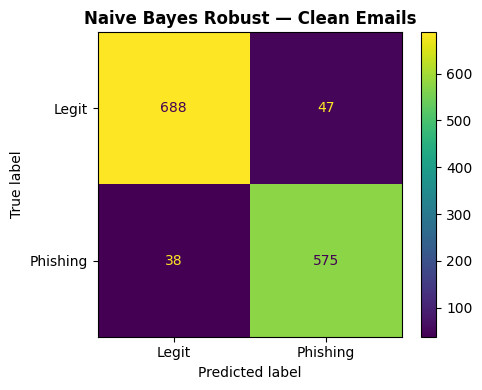

In [43]:
# Robust NB — Clean
nb_r_prob_clean = nb_robust.predict_proba(X_test_robust_clean)[:, 1]
nb_r_pred_clean = nb_robust.predict(X_test_robust_clean)
evaluate("Naive Bayes (Robust)", y_test, nb_r_pred_clean, nb_r_prob_clean, split="clean")
plot_cm(y_test, nb_r_pred_clean, "Naive Bayes Robust — Clean Emails")


=== Naive Bayes (Robust)  [MANIP] ===
              precision    recall  f1-score   support

       Legit       0.97      0.91      0.94       735
    Phishing       0.90      0.96      0.93       613

    accuracy                           0.93      1348
   macro avg       0.93      0.93      0.93      1348
weighted avg       0.93      0.93      0.93      1348

AUC : 0.9829
EER : 0.0680  (lower is better)


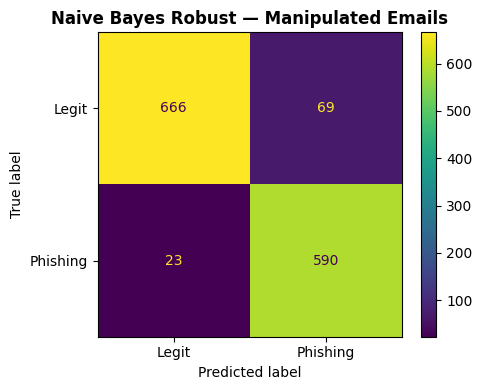

In [44]:
# Robust NB — Manipulated
nb_r_prob_manip = nb_robust.predict_proba(X_test_robust_manip)[:, 1]
nb_r_pred_manip = nb_robust.predict(X_test_robust_manip)
evaluate("Naive Bayes (Robust)", y_test, nb_r_pred_manip, nb_r_prob_manip, split="manip")
plot_cm(y_test, nb_r_pred_manip, "Naive Bayes Robust — Manipulated Emails")


=== Logistic Regression (Robust)  [CLEAN] ===
              precision    recall  f1-score   support

       Legit       0.98      0.97      0.97       735
    Phishing       0.96      0.97      0.97       613

    accuracy                           0.97      1348
   macro avg       0.97      0.97      0.97      1348
weighted avg       0.97      0.97      0.97      1348

AUC : 0.9960
EER : 0.0327  (lower is better)


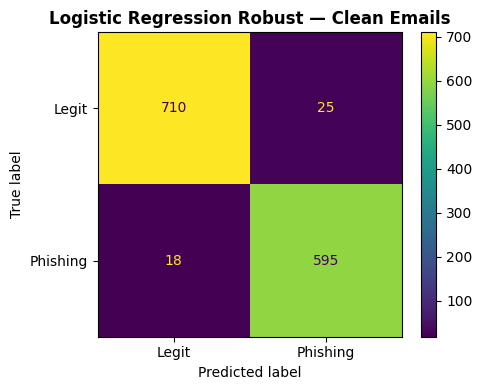

In [45]:
# Robust LR — Clean
lr_r_prob_clean = lr_robust.predict_proba(X_test_robust_clean)[:, 1]
lr_r_pred_clean = lr_robust.predict(X_test_robust_clean)
evaluate("Logistic Regression (Robust)", y_test, lr_r_pred_clean, lr_r_prob_clean, split="clean")
plot_cm(y_test, lr_r_pred_clean, "Logistic Regression Robust — Clean Emails")


=== Logistic Regression (Robust)  [MANIP] ===
              precision    recall  f1-score   support

       Legit       0.99      0.97      0.98       735
    Phishing       0.96      0.99      0.98       613

    accuracy                           0.98      1348
   macro avg       0.98      0.98      0.98      1348
weighted avg       0.98      0.98      0.98      1348

AUC : 0.9972
EER : 0.0272  (lower is better)


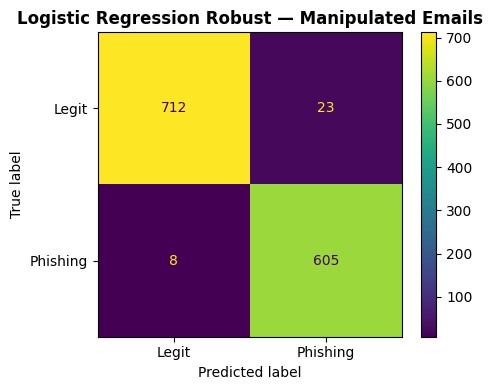

In [46]:
# Robust LR — Manipulated
lr_r_prob_manip = lr_robust.predict_proba(X_test_robust_manip)[:, 1]
lr_r_pred_manip = lr_robust.predict(X_test_robust_manip)
evaluate("Logistic Regression (Robust)", y_test, lr_r_pred_manip, lr_r_prob_manip, split="manip")
plot_cm(y_test, lr_r_pred_manip, "Logistic Regression Robust — Manipulated Emails")

In [47]:
# Build MLP — uses sparse_input=True to avoid RAM crash
def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,), sparse=True),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_model = build_mlp(X_train_robust.shape[1])
mlp_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,497 (2.48 MB)

 Trainable params: 650,497 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Train MLP with sparse data
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print('Training MLP...')
mlp_history = mlp_model.fit(
    X_train_robust, y_train_robust,
    epochs=50,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)
print(f'Training stopped at epoch {len(mlp_history.history["loss"])}')

Training MLP...
Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9313 - loss: 0.2155 - val_accuracy: 0.9722 - val_loss: 0.0753
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9854 - loss: 0.0427 - val_accuracy: 0.9771 - val_loss: 0.0731
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9931 - loss: 0.0190 - val_accuracy: 0.9784 - val_loss: 0.0836
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9974 - loss: 0.0085 - val_accuracy: 0.9814 - val_loss: 0.0784
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9972 - loss: 0.0075 - val_accuracy: 0.9765 - val_loss: 0.0915
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9985 - loss: 0.0044 - val_accuracy: 0.9765 - val_loss: 0.0904
Epoch 7/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9992 - loss: 0.0026 - val_accuracy: 0.9771 - val_loss: 0.1047
Training stopped at epoch 7


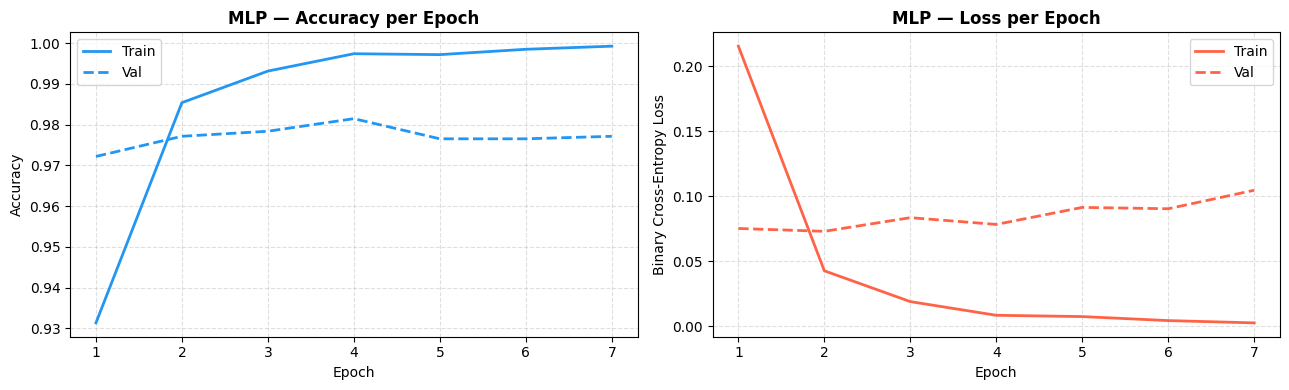

In [49]:
plot_training_history(mlp_history, 'MLP')

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=== MLP  [CLEAN] ===
              precision    recall  f1-score   support

       Legit       0.98      0.98      0.98       735
    Phishing       0.97      0.97      0.97       613

    accuracy                           0.97      1348
   macro avg       0.97      0.97      0.97      1348
weighted avg       0.97      0.97      0.97      1348

AUC : 0.9975
EER : 0.0231  (lower is better)


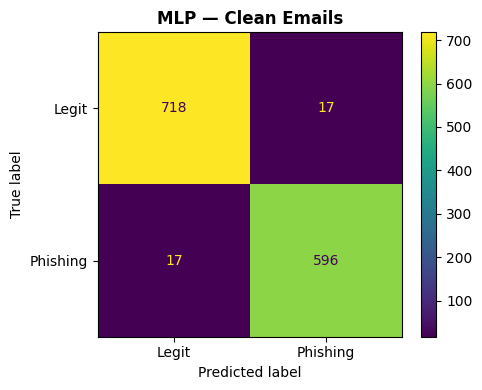

In [50]:
# MLP — Clean
mlp_prob_clean = mlp_model.predict(X_test_robust_clean).flatten()
mlp_pred_clean = (mlp_prob_clean >= 0.5).astype(int)
evaluate('MLP', y_test, mlp_pred_clean, mlp_prob_clean, split='clean')
plot_cm(y_test, mlp_pred_clean, 'MLP — Clean Emails')

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

=== MLP  [MANIP] ===
              precision    recall  f1-score   support

       Legit       0.99      0.96      0.98       735
    Phishing       0.96      0.99      0.98       613

    accuracy                           0.98      1348
   macro avg       0.98      0.98      0.98      1348
weighted avg       0.98      0.98      0.98      1348

AUC : 0.9975
EER : 0.0218  (lower is better)


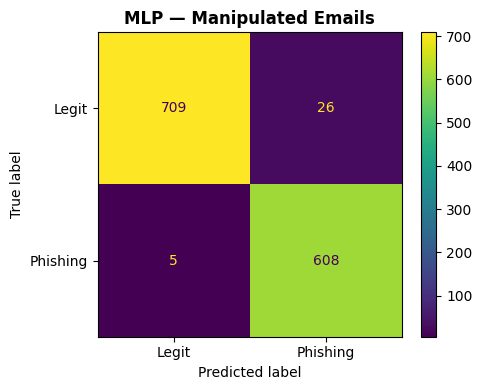

In [51]:
# MLP — Manipulated
mlp_prob_manip = mlp_model.predict(X_test_robust_manip).flatten()
mlp_pred_manip = (mlp_prob_manip >= 0.5).astype(int)
evaluate('MLP', y_test, mlp_pred_manip, mlp_prob_manip, split='manip')
plot_cm(y_test, mlp_pred_manip, 'MLP — Manipulated Emails')

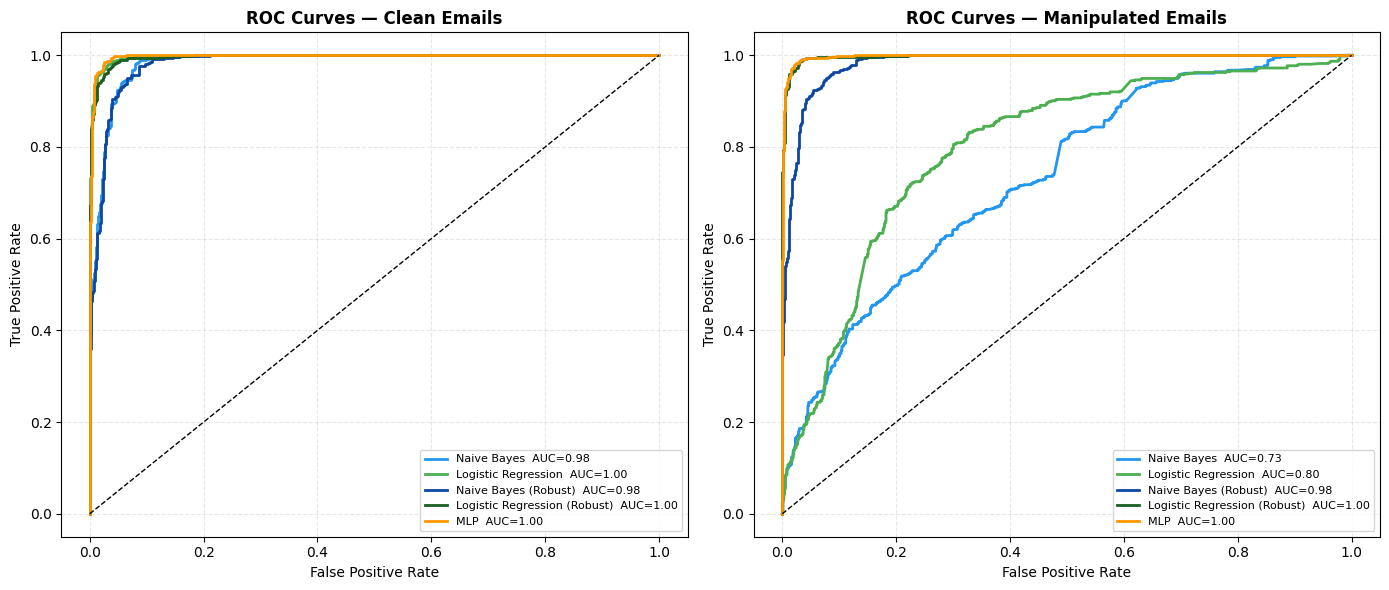

In [54]:
# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = {
    'Naive Bayes': '#2196F3',
    'Logistic Regression': '#4CAF50',
    'MLP': '#FF9800',
    'Naive Bayes (Robust)': '#0D47A1',
    'Logistic Regression (Robust)': '#1B5E20'
}

for ax, split, title in zip(axes, ['clean', 'manip'], ['Clean Emails', 'Manipulated Emails']):
    for name, data in roc_data.items():
        if split in data:
            fpr, tpr, roc_auc = data[split]
            ax.plot(fpr, tpr, label=f'{name}  AUC={roc_auc:.2f}', color=colors[name], linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves — {title}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

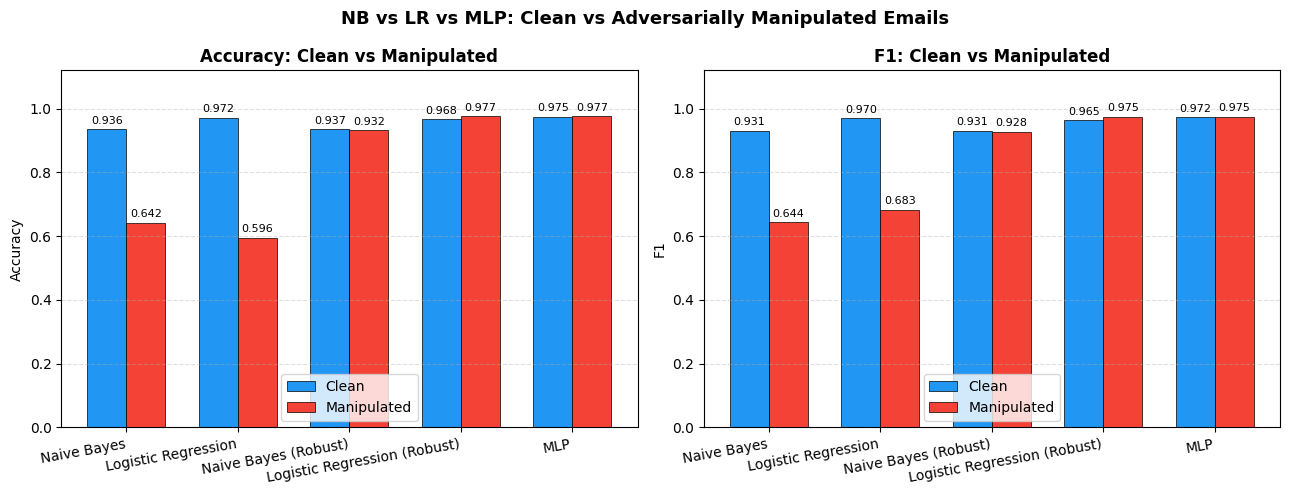

In [55]:
# Bar chart
model_names = list(results_clean.keys())
x     = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, ['Accuracy', 'F1']):
    clean_vals = [results_clean[m][metric] for m in model_names]
    manip_vals = [results_manip[m][metric] for m in model_names]

    b1 = ax.bar(x - width/2, clean_vals, width, label='Clean',       color='#2196F3', edgecolor='black', linewidth=0.5)
    b2 = ax.bar(x + width/2, manip_vals, width, label='Manipulated', color='#F44336', edgecolor='black', linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=10, ha='right')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.12)
    ax.set_title(f'{metric}: Clean vs Manipulated', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('NB vs LR vs MLP: Clean vs Adversarially Manipulated Emails', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

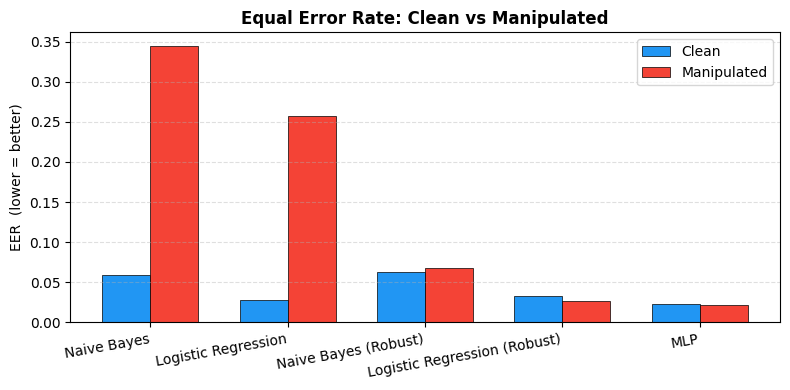

In [56]:
# EER
eer_clean = [results_clean[m]['EER'] for m in model_names]
eer_manip = [results_manip[m]['EER'] for m in model_names]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, eer_clean, width, label='Clean',       color='#2196F3', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, eer_manip, width, label='Manipulated', color='#F44336', edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=10, ha='right')
ax.set_ylabel('EER  (lower = better)')
ax.set_title('Equal Error Rate: Clean vs Manipulated', fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('eer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
# Summary Tables
metric_cols = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC', 'EER']

clean_df = pd.DataFrame(results_clean).T[metric_cols]
manip_df = pd.DataFrame(results_manip).T[metric_cols]

print('\n' + '='*65)
print('  CLEAN EMAILS')
print('='*65)
print(clean_df.round(4).to_string())

print('\n' + '='*65)
print('  MANIPULATED EMAILS')
print('='*65)
print(manip_df.round(4).to_string())


  CLEAN EMAILS
                              Accuracy      F1  Precision  Recall     AUC     EER
Naive Bayes                     0.9362  0.9310     0.9163  0.9462  0.9842  0.0585
Logistic Regression             0.9718  0.9695     0.9542  0.9853  0.9970  0.0286
Naive Bayes (Robust)            0.9369  0.9312     0.9244  0.9380  0.9829  0.0626
Logistic Regression (Robust)    0.9681  0.9651     0.9597  0.9706  0.9960  0.0327
MLP                             0.9748  0.9723     0.9723  0.9723  0.9975  0.0231

  MANIPULATED EMAILS
                              Accuracy      F1  Precision  Recall     AUC     EER
Naive Bayes                     0.6424  0.6440     0.5884  0.7113  0.7330  0.3442
Logistic Regression             0.5957  0.6833     0.5307  0.9592  0.7998  0.2571
Naive Bayes (Robust)            0.9318  0.9277     0.8953  0.9625  0.9829  0.0680
Logistic Regression (Robust)    0.9770  0.9750     0.9634  0.9869  0.9972  0.0272
MLP                             0.9770  0.9751     0.9590  0